  ## 02 – Trend & Smoothing Methods

This notebook explores smoothing techniques:

- Simple Moving Average (SMA)
- Rolling Statistics
- Exponentially Weighted Moving Average (EWMA)
- ETS (Exponential Smoothing)

Goal: Understand underlying trend and seasonality before ARIMA modeling.

In [21]:
import sys
import os
import importlib

sys.path.append(os.path.abspath("../src"))

import data_loader

importlib.reload(data_loader)
from data_loader import load_ng_consumption

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.metrics import mean_absolute_error

plt.style.use("seaborn-v0_8")



In [12]:
df = load_ng_consumption("../data/NaturalGasConsumption.xls")

df.head()

,U.S. Natural Gas Total Consumption (Bcf),Year,Month,Quarter
Date,,,,
2001-01-01,2676.998,2001,1,1
2001-02-01,2309.464,2001,2,1
2001-03-01,2246.633,2001,3,1
2001-04-01,1807.170,2001,4,2
2001-05-01,1522.382,2001,5,2


## Simple Moving Averages

### 1. Overview

The **Simple Moving Average (SMA)** is one of the most fundamental smoothing techniques used in time series analysis and forecasting. It is designed to reduce short-term fluctuations (noise) in data and highlight longer-term patterns such as trends.

SMA works by calculating the average of the most recent **k observations**, where k is called the *window size*.

---

### 2. Mathematical Definition

Given a time series:

Y₁, Y₂, Y₃, ..., Yₜ

The Simple Moving Average of order k at time t is defined as:

SMAₜ = (Yₜ₋₁ + Yₜ₋₂ + ... + Yₜ₋ₖ) / k

Where:

- k = number of observations in the moving window
- Yₜ = actual value at time t
- SMAₜ = average of the previous k observations

---

### 3. Intuition Behind SMA

The key idea behind SMA is smoothing.

Instead of relying on a single data point (which may be noisy), we take the average of recent observations. This reduces randomness and makes underlying patterns easier to detect.

Why this works:
- Random fluctuations tend to cancel out.
- Trends become more visible.
- Volatility is reduced.

---

### 4. Example

Suppose we have monthly demand data:

Month 1: 100  
Month 2: 120  
Month 3: 130  
Month 4: 110  

If we compute a 3-period SMA for Month 4:

SMA₄ = (100 + 120 + 130) / 3  
SMA₄ = 116.67  

So the forecast for Month 4 (or Month 5, depending on setup) would be 116.67.

---

### 5. Key Properties

#### Equal Weighting
Each observation in the window receives equal weight:

Weight = 1 / k

Unlike weighted moving averages, SMA does not prioritize recent observations.

---

#### Sensitivity to Window Size

Small k:
- More responsive to recent changes
- Less smoothing
- Higher variance

Large k:
- More smoothing
- Slower response to change
- Higher bias

Choosing k is a bias-variance tradeoff.

---

### 6. Use Cases in Forecasting

SMA is useful when:

- Data has no strong trend
- Data has no strong seasonality
- You need a simple baseline model
- You want to smooth noisy time series

It is often used as a benchmark before applying more advanced models.

---

### 7. Limitations

- Cannot model seasonality explicitly
- Performs poorly with strong trends
- Gives equal importance to older observations
- Not suitable for highly dynamic systems

For more complex patterns, models such as Exponential Smoothing, Holt’s Linear Trend, or ARIMA are typically preferred.



<Axes: xlabel='Date'>

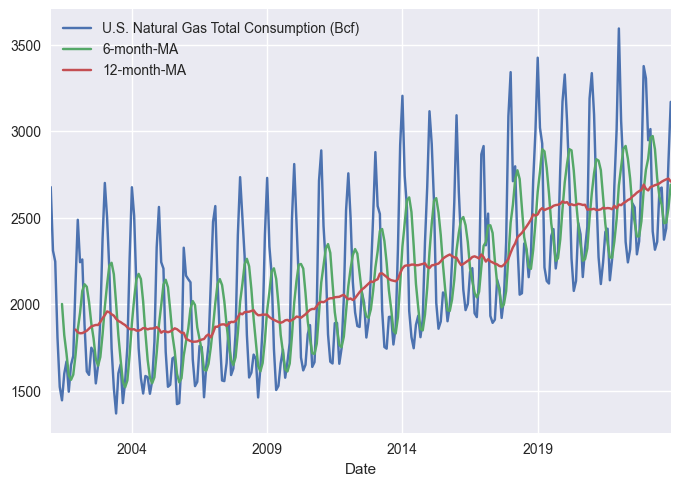

In [15]:
df['6-month-MA'] = df['U.S. Natural Gas Total Consumption (Bcf)'].rolling(window=6).mean()
df['12-month-MA'] = df['U.S. Natural Gas Total Consumption (Bcf)'].rolling(window=12).mean()
df[['U.S. Natural Gas Total Consumption (Bcf)','6-month-MA','12-month-MA']].plot()

## Rolling Standard Deviation

### 1. Overview

**Rolling Standard Deviation** (also called Moving Standard Deviation) is a time series technique used to measure how volatility changes over time.

While a moving average smooths the level of a series, rolling standard deviation measures the **dispersion (variability)** of recent observations within a moving window.

It is commonly used in:

- Financial time series (volatility measurement)
- Demand forecasting (stability analysis)
- Anomaly detection
- Risk modeling

---

### 2. Mathematical Definition

Given a time series:

Y₁, Y₂, Y₃, ..., Yₜ

The rolling standard deviation with window size k at time t is:

σₜ = sqrt( (1/k) * Σ (Yᵢ - μₜ)² )

Where:

- k = window size
- μₜ = rolling mean over the last k observations
- Yᵢ = observations within the rolling window
- σₜ = rolling standard deviation at time t

More explicitly:

1. Compute rolling mean:
   μₜ = (Yₜ₋₁ + Yₜ₋₂ + ... + Yₜ₋ₖ) / k

2. Compute variance within the window:
   Varianceₜ = (1/k) * Σ (Yᵢ - μₜ)²

3. Take square root:
   σₜ = sqrt(Varianceₜ)

---

### 3. Intuition

Rolling standard deviation tells us:

> “How spread out are the most recent k observations?”

If values within the window are close to each other → low rolling standard deviation  
If values vary widely → high rolling standard deviation  

It captures **local volatility** rather than overall volatility of the entire dataset.

---

### 4. Example

Suppose we have the following 3-period window:

100, 120, 130

Step 1: Compute mean  
μ = (100 + 120 + 130) / 3 = 116.67  

Step 2: Compute squared deviations  

(100 − 116.67)²  
(120 − 116.67)²  
(130 − 116.67)²  

Step 3: Average and take square root  

This produces the rolling standard deviation for that window.

---

### 5. Why Rolling Standard Deviation Matters in Forecasting

#### Detecting Volatility Regimes
It helps identify:

- Stable periods (low variance)
- High volatility periods (large fluctuations)
- Structural changes in the series

---

#### Checking Model Assumptions

Many time series models assume:

- Constant variance (homoscedasticity)

If rolling standard deviation changes over time, the data may exhibit:

- Heteroscedasticity
- Time-varying volatility

---

#### Anomaly Detection

Large spikes in rolling standard deviation may indicate:

- Outliers
- Sudden shocks
- Regime changes

---

### 6. Window Size Sensitivity

Small window (k small):
- Captures short-term volatility
- More sensitive to noise
- Higher variability in the metric itself

Large window (k large):
- Captures long-term volatility trends
- Smoother estimate
- Slower to detect sudden changes

Choosing k depends on the time granularity of the problem (daily, weekly, monthly).

---

### 7. Relationship with Rolling Mean

Rolling Mean → measures level  
Rolling Standard Deviation → measures spread  

Together they describe:

- Central tendency
- Dispersion
- Stability of the time series

---

### 8. Practical Interpretation

If rolling standard deviation is:

Low and stable → The series is consistent  
Increasing → Volatility is rising  
Decreasing → Series is stabilizing  
Highly fluctuating → System may be unstable  

---

### 9. Applications in Data Science

- Financial volatility modeling
- Risk management
- Forecast confidence estimation
- Feature engineering for ML models
- Time series diagnostics

---

### 10. Key Takeaway

Rolling Standard Deviation provides a dynamic view of variability in a time series. 

It helps answer:

"Is the system becoming more stable or more volatile over time?"

In forecasting workflows, it is a powerful diagnostic tool to understand structural changes and volatility patterns before selecting a model.

<Axes: xlabel='Date'>

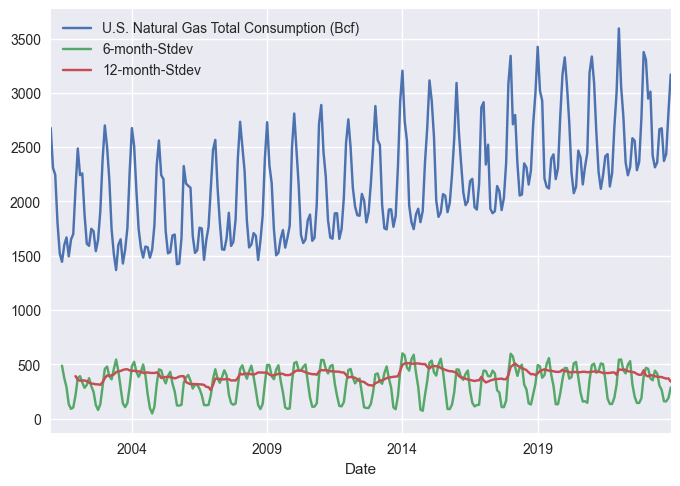

In [6]:
df['6-month-Stdev'] = df['U.S. Natural Gas Total Consumption (Bcf)'].rolling(window=6).std()
df['12-month-Stdev'] = df['U.S. Natural Gas Total Consumption (Bcf)'].rolling(window=12).std()
df[['U.S. Natural Gas Total Consumption (Bcf)','6-month-Stdev','12-month-Stdev']].plot()


## ETS Modeling

### 1. Overview

**ETS modeling** is a family of time series forecasting methods based on 
**Exponential Smoothing**.

ETS stands for:

- E → Error
- T → Trend
- S → Seasonality

The model describes how these three components interact to generate a time series.

Unlike simple moving averages, ETS models:
- Assign more weight to recent observations
- Explicitly model trend
- Explicitly model seasonality
- Adapt dynamically over time

ETS models are widely used in business forecasting because they are:
- Interpretable
- Computationally efficient
- Strong baseline models for many real-world datasets

---

### 2. Time Series Decomposition Concept

A time series can often be decomposed into:

Yₜ = Level + Trend + Seasonality + Error

ETS models formalize this structure using smoothing equations.

There are two main ways components combine:

Additive:
Yₜ = Lₜ + Tₜ + Sₜ + eₜ

Multiplicative:
Yₜ = Lₜ × Tₜ × Sₜ × eₜ

---

### 3. Components of ETS

#### 3.1 Level (Lₜ)

Represents the baseline value of the series at time t.

It is updated using exponential smoothing:

Lₜ = αYₜ + (1 − α)Lₜ₋₁

Where:
- α (alpha) = smoothing parameter (0 < α < 1)

Higher α → more weight to recent data  
Lower α → smoother level estimate  

---

#### 3.2 Trend (Tₜ)

Captures upward or downward movement over time.

Updated using:

Tₜ = β(Lₜ − Lₜ₋₁) + (1 − β)Tₜ₋₁

Where:
- β (beta) = trend smoothing parameter

---

#### 3.3 Seasonality (Sₜ)

Captures repeating patterns (monthly, quarterly, etc.)

Updated using:

Additive:
Sₜ = γ(Yₜ − Lₜ) + (1 − γ)Sₜ₋ₘ

Multiplicative:
Sₜ = γ(Yₜ / Lₜ) + (1 − γ)Sₜ₋ₘ

Where:
- γ (gamma) = seasonal smoothing parameter
- m = seasonal period (e.g., 12 for monthly data)

---

### 4. Error Component

The error term describes how randomness enters the model.

There are two types:

Additive Error:
Yₜ = Forecastₜ + eₜ

Multiplicative Error:
Yₜ = Forecastₜ × (1 + eₜ)

The combination of error, trend, and seasonality type defines the full ETS model.

---

### 5. Model Naming Convention

ETS models are written as:

ETS(Error, Trend, Seasonality)

Examples:

ETS(A, N, N)
- Additive error
- No trend
- No seasonality
(Simple Exponential Smoothing)

ETS(A, A, N)
- Additive error
- Additive trend
- No seasonality
(Holt’s Linear Trend)

ETS(A, A, A)
- Additive error
- Additive trend
- Additive seasonality
(Holt-Winters Additive)

ETS(M, A, M)
- Multiplicative error
- Additive trend
- Multiplicative seasonality

---

### 6. Additive vs Multiplicative

Additive Seasonality:
- Seasonal variation remains constant over time
- Example: +10 units every December

Multiplicative Seasonality:
- Seasonal variation grows with level
- Example: +10% every December

Choose multiplicative when variance increases with the level.

---

### 7. Forecast Equation

For an additive ETS model:

Forecastₜ₊ₕ = Lₜ + hTₜ + Sₜ₊ₕ₋ₘ

Where:
- h = forecast horizon
- Lₜ = level at time t
- Tₜ = trend at time t
- S = seasonal component

---

### 8. Why ETS is Powerful

✔ Handles trend and seasonality explicitly  
✔ Automatically adapts to changes  
✔ Works well for business and economic data  
✔ Often outperforms naive models  

It is widely used in:
- Retail demand forecasting
- Energy consumption forecasting
- Financial forecasting
- Inventory planning

---

### 9. When to Use ETS

Use ETS when:

- Data has trend and/or seasonality
- You want an interpretable model
- You need fast computation
- ARIMA feels unnecessarily complex

---

### 10. Limitations

- Assumes structure is relatively stable
- Not ideal for highly irregular patterns
- Struggles with sudden structural breaks
- Less suitable for multivariate forecasting

---

### 11. Key Takeaway

ETS modeling is a structured and systematic way of combining:

Level + Trend + Seasonality + Error

It is one of the most practical and widely used forecasting frameworks in applied data science.

In many real-world business settings, a well-tuned ETS model performs extremely well and serves as a strong benchmark against more complex models.

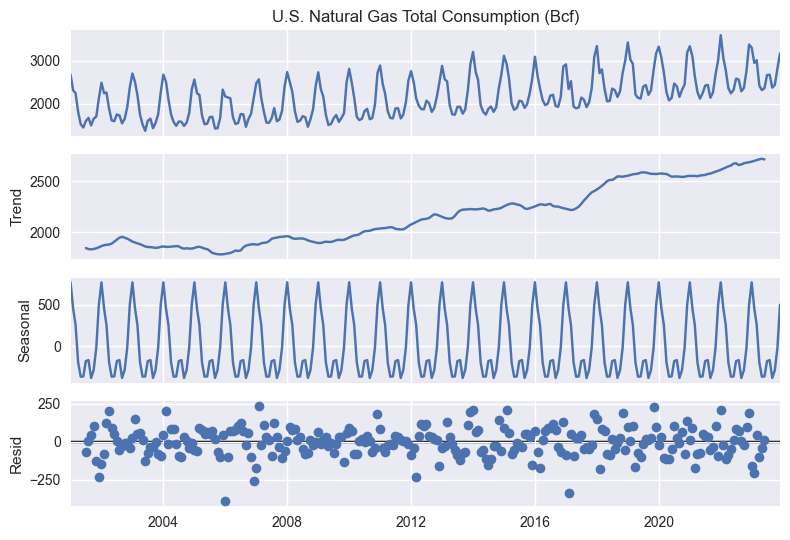

In [16]:
result = seasonal_decompose(
    df['U.S. Natural Gas Total Consumption (Bcf)'],
    model="additive",
    period=12
)
result.plot() 
plt.show()

In [18]:
ets_model = ExponentialSmoothing(
    df['U.S. Natural Gas Total Consumption (Bcf)'][:-12],
    trend="add",  # or "mul"
    seasonal="add",  # or  "mul"
    seasonal_periods=12
)

model_fit = ets_model.fit()

forecast = model_fit.forecast(12)

In [25]:
model_fit.params

{'smoothing_level': np.float64(0.38193463241717784),
 'smoothing_trend': np.float64(0.0),
 'smoothing_seasonal': np.float64(0.13804986865453725),
 'damping_trend': nan,
 'initial_level': np.float64(1913.4095357599629),
 'initial_trend': np.float64(3.20233788338753),
 'initial_seasons': array([ 705.72124937,  443.23439469,  277.5488249 , -120.36122841,
        -312.28978837, -341.02807657, -181.94823086, -157.69375867,
        -360.81303925, -249.9634341 ,  -47.4484381 ,  435.11958233]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

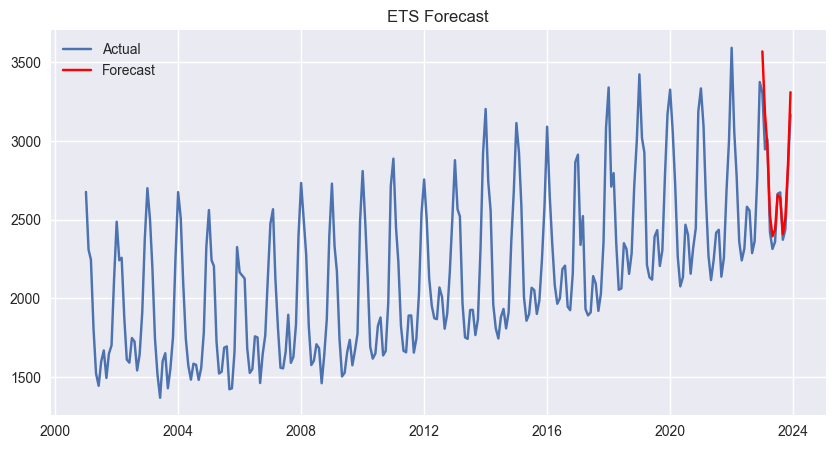

In [20]:
plt.figure(figsize=(10,5))

plt.plot(df.index, df["U.S. Natural Gas Total Consumption (Bcf)"], label="Actual")
plt.plot(forecast.index, forecast, label="Forecast", color="red")

plt.legend()
plt.title("ETS Forecast")
plt.show()

In [22]:
mae = mean_absolute_error(df['U.S. Natural Gas Total Consumption (Bcf)'][-12:], forecast)
print("MAE:", mae)

MAE: 92.71739178723033


## EWMA - Exponential Weighted Moving Average

### 1. Overview

The **Exponentially Weighted Moving Average (EWMA)** is a smoothing technique 
used in time series analysis that assigns **more weight to recent observations** 
and exponentially decreasing weight to older observations.

Unlike the Simple Moving Average (SMA), which gives equal weight to all points 
in the window, EWMA adapts faster to changes in the data.

EWMA is widely used in:

- Forecasting
- Financial volatility modeling
- Risk management
- Signal smoothing
- Process control

---

### 2. Mathematical Definition

The EWMA at time t is defined recursively as:

EWMAₜ = αYₜ + (1 − α)EWMAₜ₋₁

Where:

- Yₜ = actual value at time t
- EWMAₜ = smoothed value at time t
- α (alpha) = smoothing parameter (0 < α ≤ 1)

---

### 3. Understanding the Smoothing Parameter (α)

The parameter α controls how quickly the model reacts to new data.

If α is close to 1:
- More weight on recent observation
- Reacts quickly to changes
- Less smoothing

If α is close to 0:
- More weight on historical values
- Smoother curve
- Slower reaction to changes

This creates a bias-variance tradeoff similar to moving averages.

---

### 4. Expanded Form (Weight Interpretation)

If we expand the recursive equation:

EWMAₜ = αYₜ + α(1−α)Yₜ₋₁ + α(1−α)²Yₜ₋₂ + ...

This shows:

- Weights decline exponentially
- Recent values dominate
- Older observations never fully disappear (infinite memory)

This is why it is called "exponentially weighted."

---

### 5. Intuition Behind EWMA

EWMA answers the question:

"What is the current level of the series, giving more importance to recent observations?"

It smooths noise while remaining responsive to:

- Structural changes
- Trend shifts
- Sudden shocks

Compared to SMA:
- No fixed window
- No sharp cutoff
- Smoother transitions

---

### 6. Relationship to Simple Exponential Smoothing

EWMA is mathematically equivalent to:

Simple Exponential Smoothing (SES)

Forecast equation:

Forecastₜ₊₁ = EWMAₜ

It is essentially the simplest form of the ETS framework:

ETS(A, N, N)
- Additive error
- No trend
- No seasonality

---

### 7. Example

Suppose:

Y₁ = 100  
Y₂ = 120  
Y₃ = 130  

Let α = 0.3

Step 1:
EWMA₁ = Y₁ = 100 (initialization)

Step 2:
EWMA₂ = 0.3(120) + 0.7(100) = 106

Step 3:
EWMA₃ = 0.3(130) + 0.7(106) = 113.2

Notice how recent values influence the estimate more strongly.

---

### 8. Key Properties

✔ More weight to recent data  
✔ Infinite memory with exponential decay  
✔ No fixed window size  
✔ Smooth and adaptive  

---

### 9. When to Use EWMA

EWMA works well when:

- Data has no strong seasonality
- You need a fast adaptive smoother
- You want a simple baseline forecasting model
- The series evolves gradually over time

It is often preferred over SMA because it:

- Avoids abrupt window cutoffs
- Reacts more naturally to changes

---

### 10. Limitations

- Does not model trend explicitly
- Does not model seasonality
- Requires tuning α
- Not suitable for strongly seasonal data without extensions

For trend and seasonality, extended models like Holt’s Linear Trend or Holt-Winters are used.

---

### 11. Key Takeaway

EWMA provides a dynamic and adaptive smoothing method that:

- Emphasizes recent information
- Reduces noise
- Forms the foundation of exponential smoothing methods
- Serves as the starting point for the full ETS framework

In practical forecasting workflows, EWMA is often the first 
"intelligent" model beyond simple averages.

<Axes: xlabel='Date'>

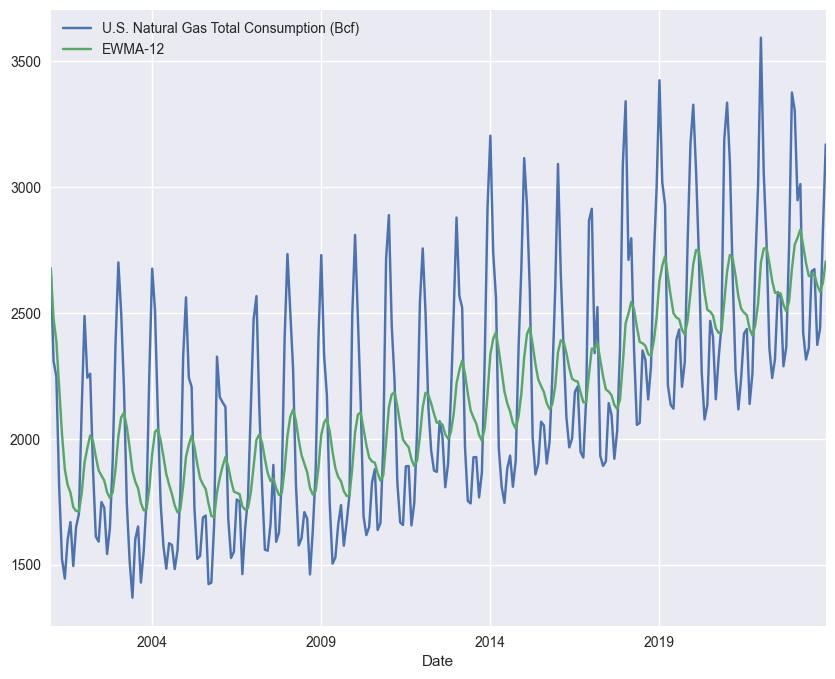

In [17]:
df['EWMA-12'] = df['U.S. Natural Gas Total Consumption (Bcf)'].ewm(span=12).mean()
df[["U.S. Natural Gas Total Consumption (Bcf)","EWMA-12"]].plot(figsize=(10,8))

In [24]:
df.head(10)

,U.S. Natural Gas Total Consumption (Bcf),Year,Month,Quarter,6-month-MA,12-month-MA,EWMA-12
Date,,,,,,,
2001-01-01,2676.998,2001,1,1,NaN,NaN,2676.998000
2001-02-01,2309.464,2001,2,1,NaN,NaN,2477.917083
2001-03-01,2246.633,2001,3,1,NaN,NaN,2387.646852
2001-04-01,1807.170,2001,4,2,NaN,NaN,2204.412995
2001-05-01,1522.382,2001,5,2,NaN,NaN,2019.107611
2001-06-01,1444.378,2001,6,2,2001.170833,NaN,1879.418079
2001-07-01,1598.071,2001,7,3,1821.349667,NaN,1816.636463
2001-08-01,1669.178,2001,8,3,1714.635333,NaN,1785.864155
2001-09-01,1494.128,2001,9,3,1589.217833,NaN,1728.148359
